# Bassam Kasar Car Price Prediction with Machine Learning Project



# 1. Let's first import the required libraries

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 2. Load the dataset

In [11]:
df = pd.read_csv('car data.csv')

# 3. Feature Engineering & Cleaning

In [12]:
# Create a 'Car_Age' column
df['Car_Age'] = 2026 - df['Year']

# Drop columns that won't be used for prediction
df_model = df.drop(['Car_Name', 'Year'], axis=1)

# 4. Exploratory Data Analysis (EDA) Plots

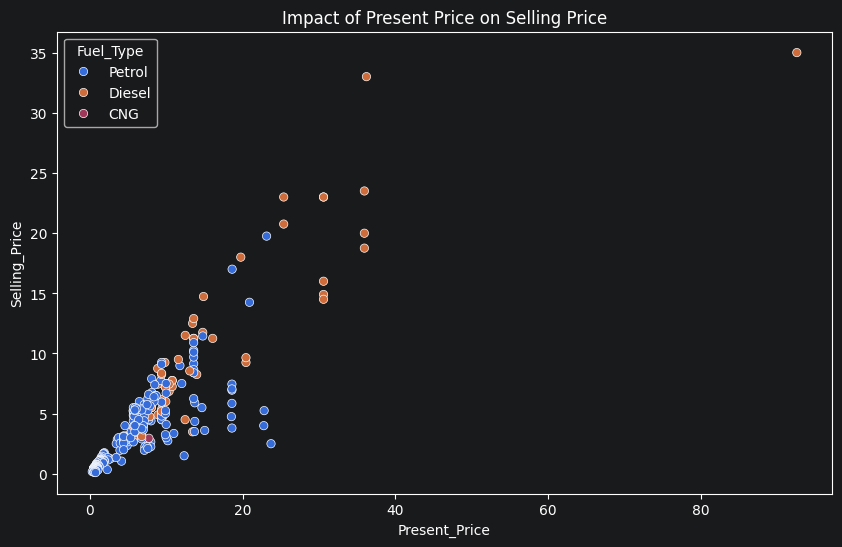

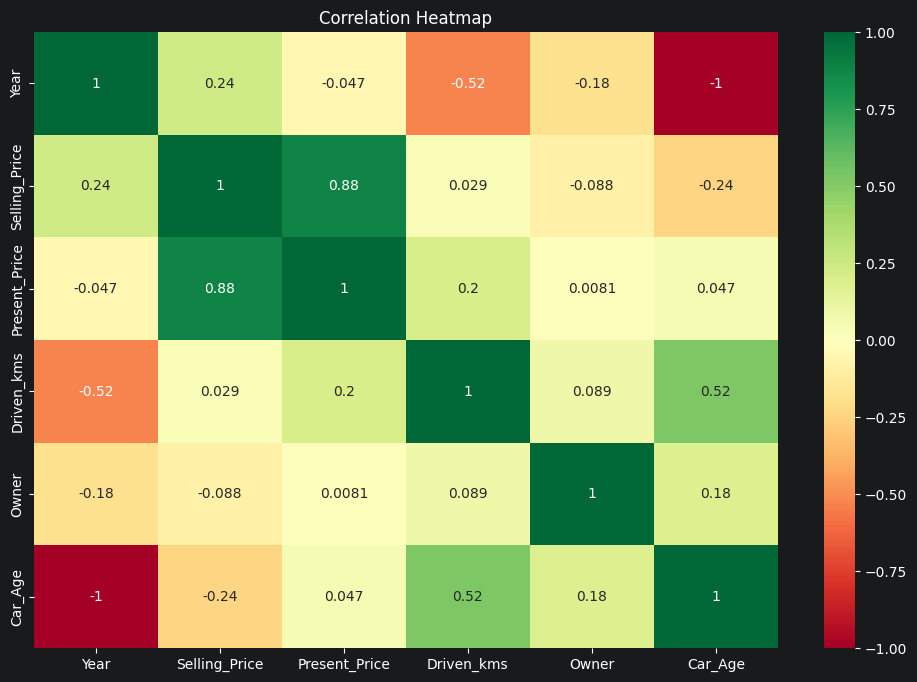

In [13]:
# Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Present_Price', y='Selling_Price', hue='Fuel_Type')
plt.title('Impact of Present Price on Selling Price')
plt.show()

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='RdYlGn')
plt.title('Correlation Heatmap')
plt.show()

# 5. Handling Categorical Data

In [14]:
# Convert text categories into numerical columns
df_final = pd.get_dummies(df_model, drop_first=True)

# Separate features (X) from the target price (y)
X = df_final.drop('Selling_Price', axis=1)
y = df_final['Selling_Price']

# 6. Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Training and Evaluation

In [16]:
# Initialize the model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
predictions = model.predict(X_test)

# Check accuracy
print(f"R2 Score: {r2_score(y_test, predictions):.2f}")
print(f"MAE: {mean_absolute_error(y_test, predictions):.2f}")

R2 Score: 0.96
MAE: 0.64
